# Pronóstico de la Tasa de Desempleo — Comparación de Modelos
## Series de Tiempo Univariadas · Universidad Nacional de Colombia

Este notebook aplica cinco familias de modelos para predecir la tasa de desempleo mensual:

| # | Familia | Sección notas |
|---|---------|--------------|
| 1 | Suavizamiento exponencial (SES, Holt, Holt-Winters) | Cap. 3 |
| 2 | Árbol de decisión | §3.8.1–3.8.3 |
| 3 | MLP (perceptrón multicapa) | §3.8.5 |
| 4 | RNN simple | §3.9 |
| 5 | LSTM | §3.9 |

**Estructura general (§3.7.4):**
```
Datos  →  Train | Validation | Test
                ↓
  Para cada familia F:
    Grid de hiperparámetros λ
    → Entrenar en Train con λ fijo  (estima parámetros W, b)
    → Evaluar RMSE en Validation   (selecciona λ* = mejor hiperparámetro)
    → Reentrenar en Train+Val con λ* fijo
    → Guardar modelo final de F
  ↓
  Comparar todos los modelos finales en Test  (una sola vez)
  → Elegir ganador
```

> **Nota de diseño:** el conjunto Test se toca **exactamente una vez**, al final.
> Usarlo durante la selección de hiperparámetros inflaría artificialmente los resultados.


## 0. Instalación de dependencias y librerías

In [1]:
%load_ext rpy2.ipython

In [31]:
# ── Python ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Semilla global para reproducibilidad ────────────────────────────────────
SEED = 20260510
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Carga de datos y análisis descriptivo
Cargamos la serie de tasa de desempleo mensual y hacemos un análisis descriptivo en R
para aprovechar las funciones de series de tiempo que ya conocemos.

In [25]:
# ── Carga en Python ──────────────────────────────────────────────────────────
df = pd.read_excel("../Input/Base Series Empleo.xlsx",  sheet_name="Series de datos", skiprows=2)
df.columns = df.columns.str.replace("\xa0", " ") # Eliminar caracteres no deseados
df = df.rename(columns={
    "Unnamed: 0": "Fecha",
    "Tasa de desempleo - Total Nacional": "Desempleo"
}) # Renombrar columnas para mayor claridad
df = df[["Fecha", "Desempleo"]] # Seleccionar solo las columnas relevantes
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce") # Convertir a formato datetime, manejar errores
df = df.dropna(subset=["Fecha"]) # Eliminar filas con fechas no convertibles
df = df.sort_values("Fecha") # Asegurar que los datos estén ordenados por fecha

In [27]:
print(df.shape) #  Verificar dimensiones
df.head() # Mostrar las primeras filas para verificar la carga
# print(df.dtypes) # Verificar tipos de datos

(299, 2)


,Fecha,Desempleo
0,2001-01-31,16.622326
1,2001-02-28,17.434206
2,2001-03-31,15.811933
3,2001-04-30,14.515078
4,2001-05-31,14.035833


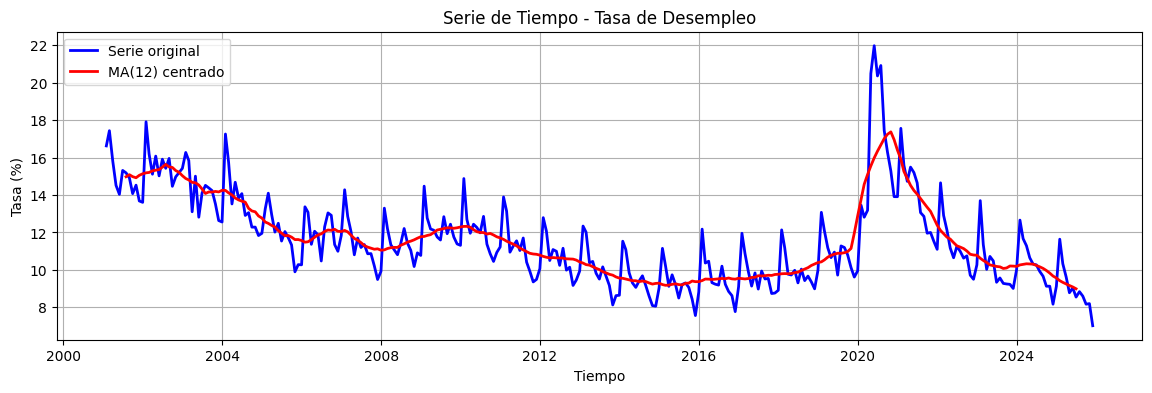

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4)) 

ax.plot(df["Fecha"], df["Desempleo"], color="blue", linewidth=2, label="Serie original") # Tasa de desempleo original

# MA(12) centrado — equivalent of stats::filter(ts_data, rep(1/12,12), sides=2)
df["MA12"] = df["Desempleo"].rolling(window=12, center=True).mean()
ax.plot(df["Fecha"], df["MA12"], color="red", linewidth=2, label="MA(12) centrado") # Promedio móvil de 12 meses centrado

ax.set_title("Serie de Tiempo - Tasa de Desempleo")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Tasa (%)")
ax.legend(loc="upper left")
ax.grid(True)
plt.show()

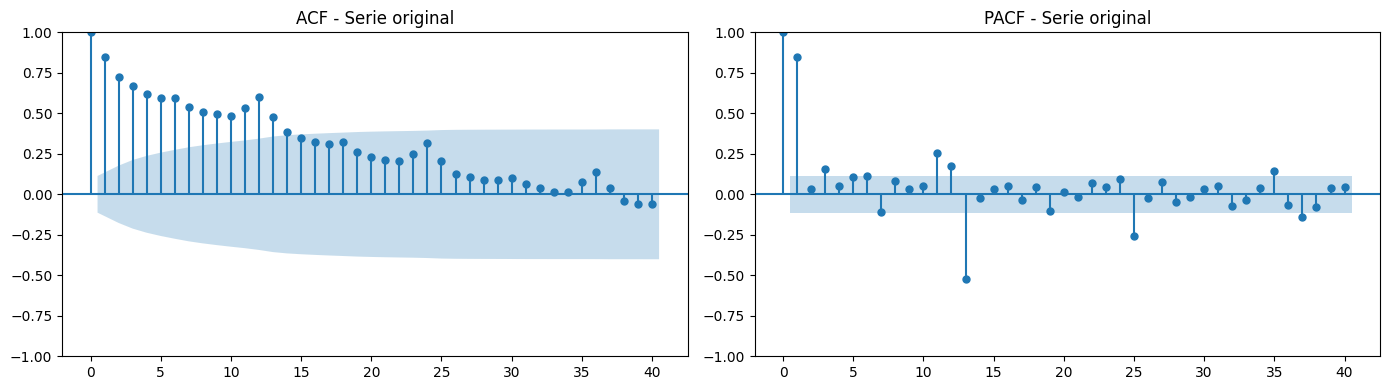

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF: correlación con cada rezago (incluye efectos indirectos)
plot_acf(df["Desempleo"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF - Serie original")

# PACF: correlación directa con el rezago h (controla los intermedios)
plot_pacf(df["Desempleo"].dropna(), lags=40, ax=axes[1])
axes[1].set_title("PACF - Serie original")

plt.tight_layout()
plt.show()

Es un modelo con tendencia clara y que no tiene decaimiento lento a 0. Es posible que tenga raíz unitaria.

### 1.1 Descomposición clásica y STL
La descomposición $$X_t = m_t + S_t + Y_t$$ (§2 notas) es el fundamento del preprocesamiento
que usaremos en todos los modelos de ML: trabajaremos con la **serie sin tendencia** para
que los modelos no necesiten extrapolar fuera del rango de entrenamiento.

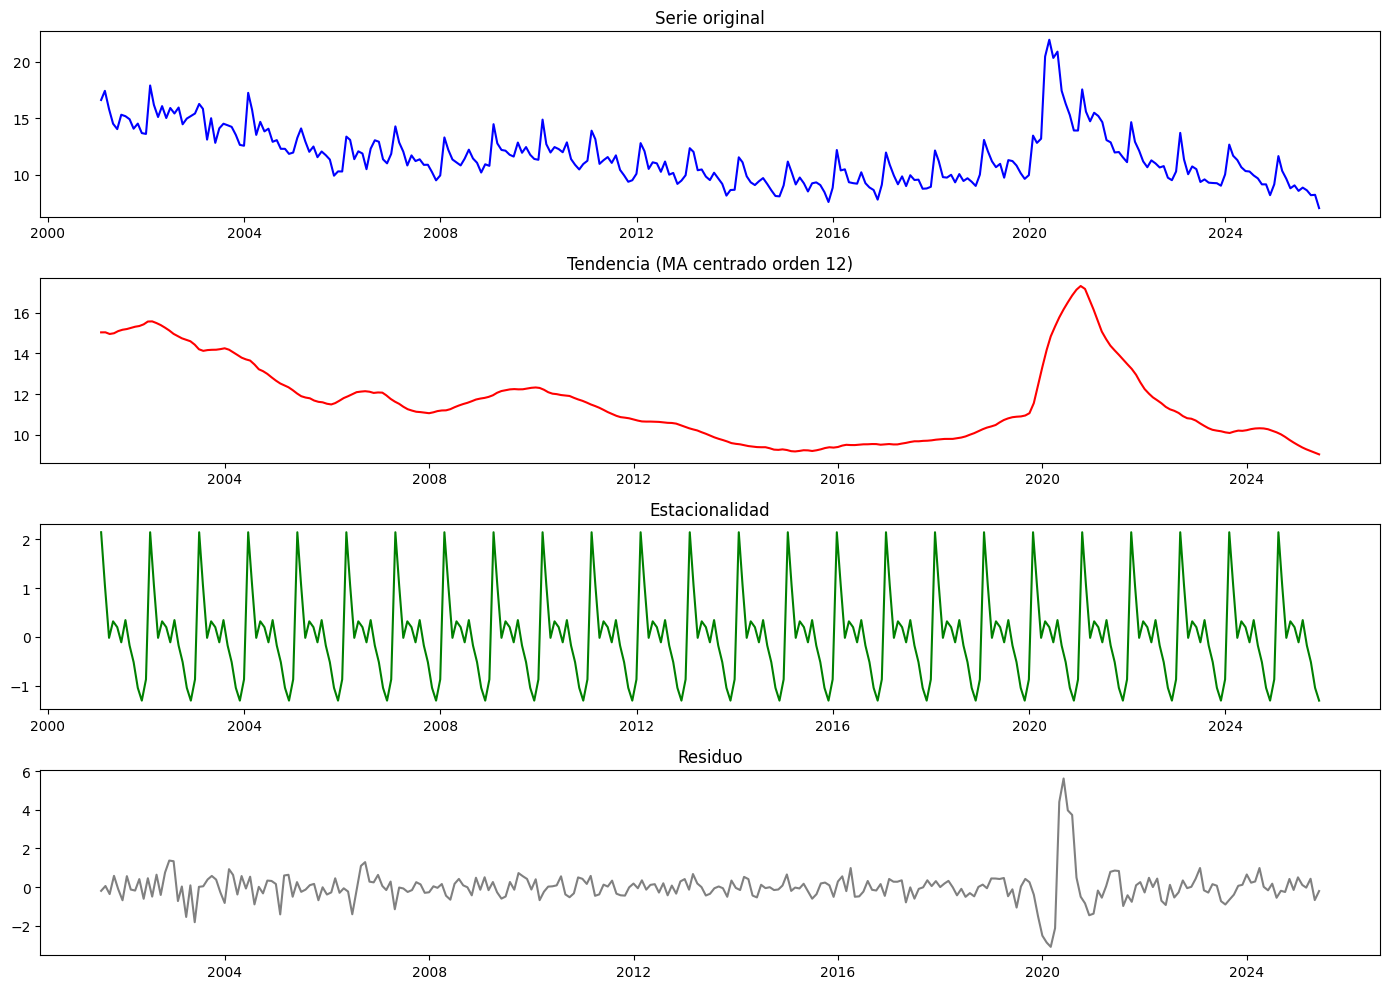

In [33]:
# La serie necesita un índice de fechas para que statsmodels entienda la frecuencia
serie = df.set_index("Fecha")["Desempleo"]
resultado = seasonal_decompose(serie, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(resultado.observed,  color="blue")
axes[0].set_title("Serie original")
axes[1].plot(resultado.trend,     color="red")
axes[1].set_title("Tendencia (MA centrado orden 12)")
axes[2].plot(resultado.seasonal,  color="green")
axes[2].set_title("Estacionalidad")
axes[3].plot(resultado.resid,     color="gray")
axes[3].set_title("Residuo")

plt.tight_layout()
plt.show()

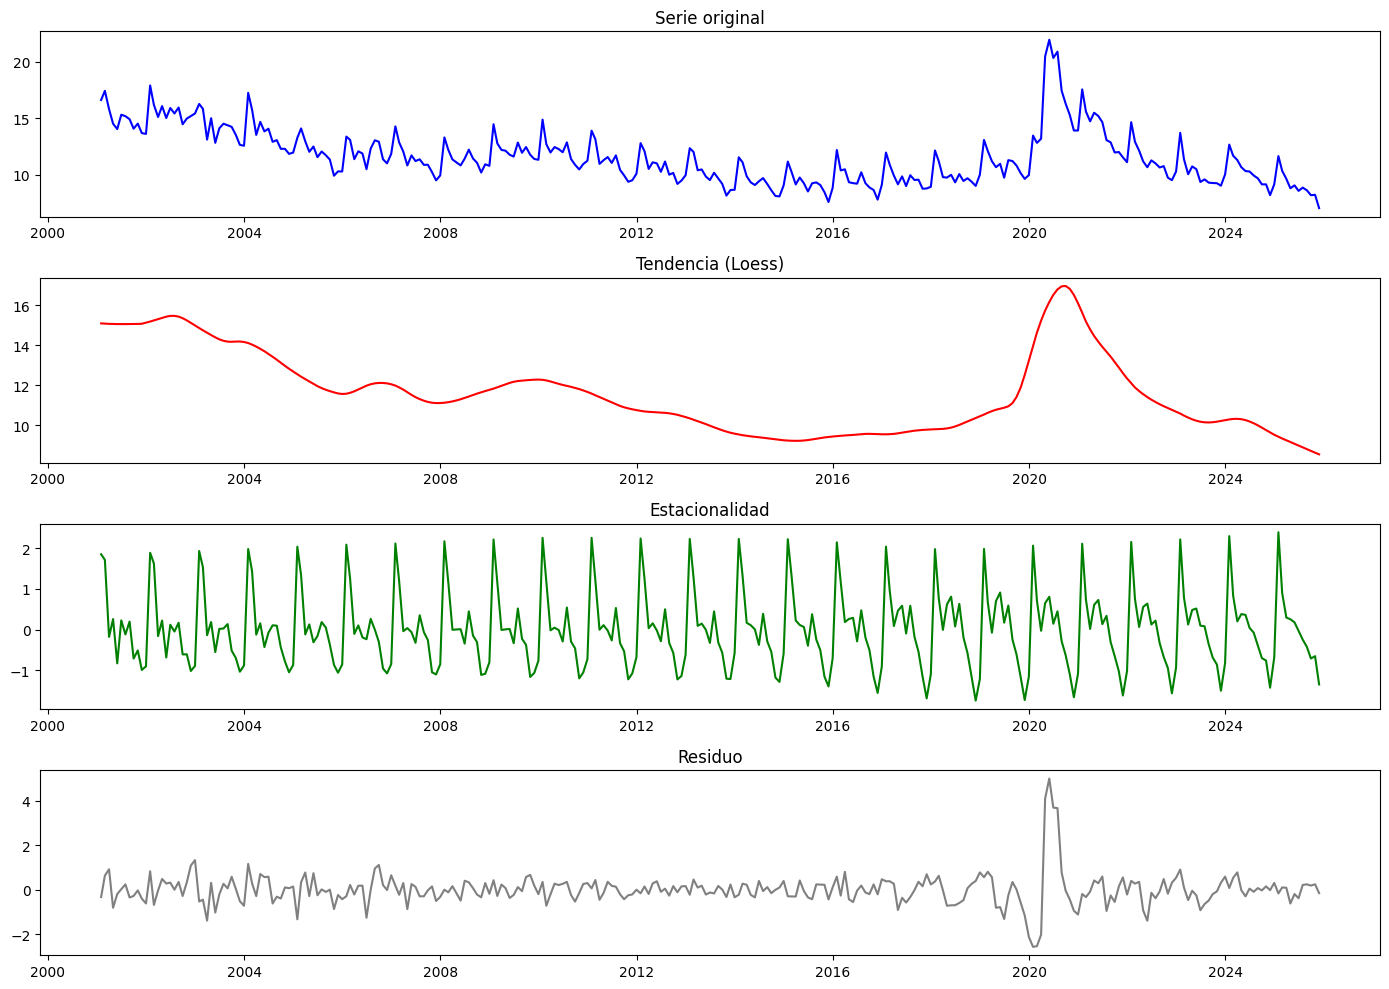

In [35]:
from statsmodels.tsa.seasonal import STL

# STL: Seasonal-Trend decomposition using Loess
# s.window="periodic" en R equivale a seasonal=13 en Python (estacionalidad fija)
resultado_stl = STL(serie, period=12, seasonal=13).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(resultado_stl.observed,  color="blue")
axes[0].set_title("Serie original")
axes[1].plot(resultado_stl.trend,     color="red")
axes[1].set_title("Tendencia (Loess)")
axes[2].plot(resultado_stl.seasonal,  color="green")
axes[2].set_title("Estacionalidad")
axes[3].plot(resultado_stl.resid,     color="gray")
axes[3].set_title("Residuo")

plt.tight_layout()
plt.show()

### 1.2 Estimación de tendencia por promedio móvil causal
Usamos la media móvil **causal** (solo pasado, align='right') para poder
aplicarla también en el período de test sin usar información futura.
Esta tendencia estimada será añadida de vuelta a las predicciones de los
modelos de ML que trabajan sobre la serie detrended.

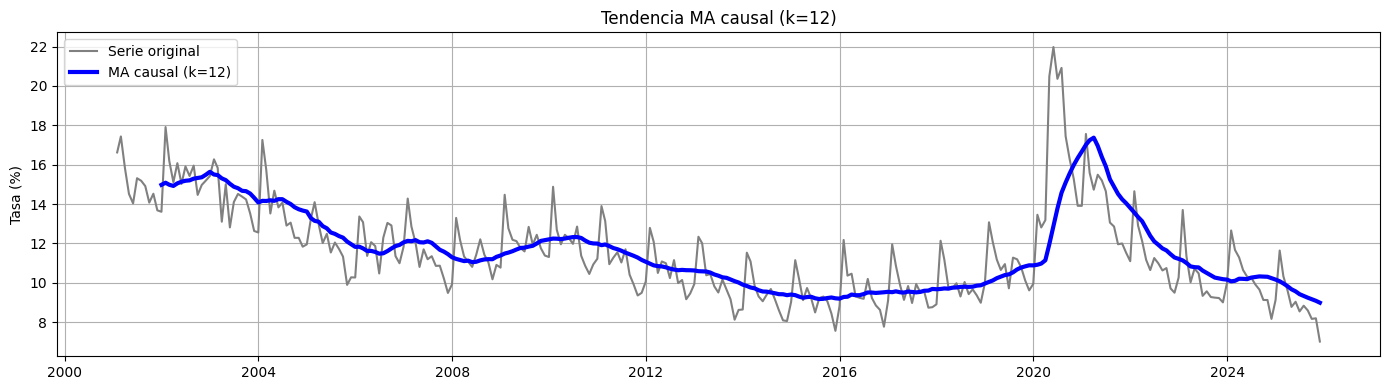

In [36]:
# ── MA causal (k=12) ─────────────────────────────────────────────────────────
# min_periods=12 → solo calcula cuando tiene 12 observaciones pasadas completas
# es equivalente a align="right" en R → NO usa información futura
k = 12
df["tendencia_ma_pasado"] = df["Desempleo"].rolling(window=k, min_periods=k).mean()

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["Fecha"], df["Desempleo"],            color="gray",  linewidth=1.5, label="Serie original")
ax.plot(df["Fecha"], df["tendencia_ma_pasado"],  color="blue",  linewidth=3,   label="MA causal (k=12)")
ax.set_title("Tendencia MA causal (k=12)")
ax.set_ylabel("Tasa (%)")
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 2. Suavizamiento Exponencial

Los modelos de suavizamiento exponencial **no requieren la división train/validation/test**
en el sentido de ML, porque sus hiperparámetros (α, β, γ) se estiman **directamente
minimizando el error en la muestra de entrenamiento** mediante optimización numérica.

Por tanto, aquí la división es solo **train / test**:
- **Train:** toda la serie excepto los últimos `h = 12` meses
- **Test:** últimos 12 meses (usados para comparar al final)

Los parámetros α, β, γ son estimados internamente por `statsmodels` vía máxima
verosimilitud / minimización de SSE.

Train ES : 287 obs  |  2001-01-31 → 2024-11-30
Test ES  : 12  obs  |  2024-12-31 → 2025-11-30


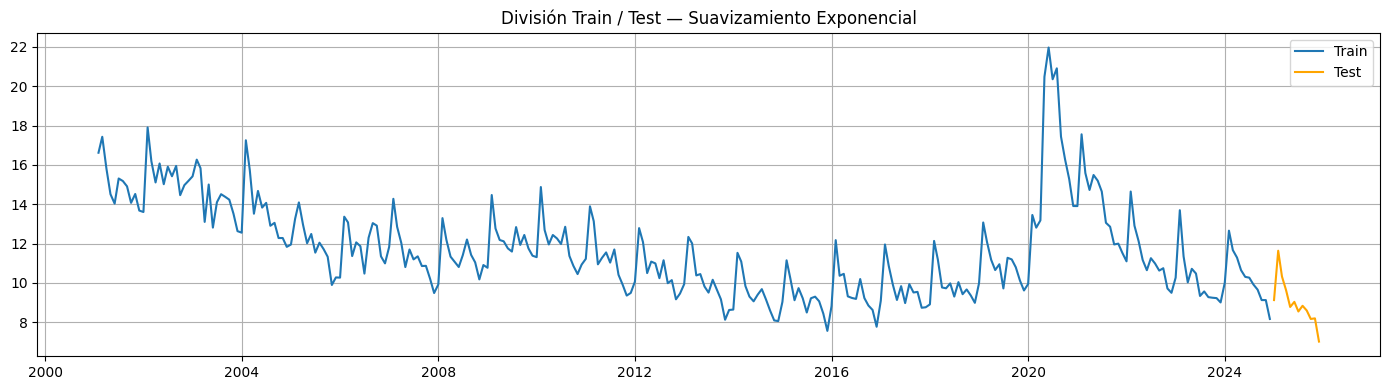

In [37]:
# ── División train / test ─────────────────────────────────────────────────────
# serie ya tiene Fecha como índice y Desempleo como valores
serie = df.set_index("Fecha")["Desempleo"]

h = 12  # horizonte de pronóstico = 12 meses

train_es = serie[:-h]   # todo excepto los últimos 12
test_es  = serie[-h:]   # últimos 12 meses

print(f"Train ES : {len(train_es)} obs  |  {train_es.index[0].date()} → {train_es.index[-1].date()}")
print(f"Test ES  : {len(test_es)}  obs  |  {test_es.index[0].date()} → {test_es.index[-1].date()}")

# ── Gráfico división ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_es, label="Train")
ax.plot(test_es,  label="Test", color="orange")
ax.set_title("División Train / Test — Suavizamiento Exponencial")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Función de métricas de error
La función calcula las tres métricas más usadas en el curso (§3.3.8):
- **MAE** — error medio absoluto
- **RMSE** — raíz del error cuadrático medio → equivale a $\sqrt{\widehat{ECM}}$
- **MAPE** — error porcentual medio absoluto

In [38]:
def metricas(y_true, y_pred, nombre=""):
    """
    Calcula MAE, RMSE y MAPE.
    RMSE = sqrt(ECM) es la métrica principal del curso (§3.3.8):
        ECM[X̂_{T+h|T}] ≈ (1 / (T-l-h+1)) Σ e²_{t,h}
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    if nombre:
        print(f"{'Modelo':<20} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}%")
        print(f"{nombre:<20} {mae:>8.4f} {rmse:>8.4f} {mape:>8.2f}")
    return mae, rmse, mape

### 2.1 SES — Suavizamiento Exponencial Simple
$$\hat{y}_{t+1} = \alpha y_t + (1-\alpha)\hat{y}_t, \quad 0 < \alpha < 1$$
- Solo un parámetro α (hiperparámetro estimado por statsmodels sobre train)
- Adecuado para series **sin tendencia ni estacionalidad**

In [39]:
# statsmodels optimiza α minimizando SSE sobre train_es internamente
modelo_ses     = SimpleExpSmoothing(train_es).fit()
forecast_ses   = modelo_ses.forecast(h)

print("Parámetro α estimado:", round(modelo_ses.params['smoothing_level'], 4))
metricas(test_es, forecast_ses, "SES")

Parámetro α estimado: 0.7851
Modelo                    MAE     RMSE     MAPE%
SES                    0.9038   1.2684     9.47


(0.90384188735571,
 np.float64(1.2684232187558415),
 np.float64(9.466624508043504))

### 2.2 Holt — Doble suavizamiento (tendencia)
Agrega un componente de tendencia β:
$$\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1}+b_{t-1})$$
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)b_{t-1}$$
- Adecuado para series **con tendencia pero sin estacionalidad**

In [42]:
modelo_holt   = Holt(train_es).fit()
forecast_holt = modelo_holt.forecast(h)

params_holt = {}
for k, v in modelo_holt.params.items():
    if callable(v) or v is None:          # skip functions AND None values
        continue
    elif hasattr(v, '__len__'):            # es un array
        params_holt[k] = [round(x, 4) for x in v]
    else:                                  # es un escalar
        params_holt[k] = round(v, 4)

print("Parámetros Holt:", params_holt)
metricas(test_es, forecast_holt, "Holt")

Parámetros Holt: {'smoothing_level': np.float64(0.8516), 'smoothing_trend': np.float64(0.0349), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(16.6223), 'initial_trend': np.float64(0.8119), 'initial_seasons': [], 'use_boxcox': 0, 'remove_bias': 0}
Modelo                    MAE     RMSE     MAPE%
Holt                   1.3501   1.5864    14.20


(1.3501317250531795,
 np.float64(1.5864388826714209),
 np.float64(14.198180491015707))

### 2.3 Holt-Winters — Triple suavizamiento (tendencia + estacionalidad)
Agrega un componente estacional γ con período d=12:
- Variante **aditiva**: $y_t = \ell_t + b_t + s_{t-d} + \varepsilon_t$
- α, β, γ son estimados internamente sobre train_es

In [44]:
modelo_hw = ExponentialSmoothing(
    train_es,
    trend            = "add",
    seasonal         = "add",
    seasonal_periods = 12
).fit()
forecast_hw = modelo_hw.forecast(h)

params_hw = {}
for k, v in modelo_hw.params.items():
    if callable(v) or v is None:       # skip functions and None
        continue
    elif hasattr(v, '__len__'):        # es un array
        params_hw[k] = [round(x, 4) for x in v]
    else:                              # es un escalar
        params_hw[k] = round(v, 4)

print("Parámetros HW:", params_hw)
metricas(test_es, forecast_hw, "Holt-Winters")

Parámetros HW: {'smoothing_level': np.float64(0.8462), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(14.7914), 'initial_trend': np.float64(-0.0181), 'initial_seasons': [np.float64(2.1132), np.float64(1.1143), np.float64(-0.0107), np.float64(0.3057), np.float64(0.151), np.float64(-0.1016), np.float64(0.3381), np.float64(-0.1876), np.float64(-0.5337), np.float64(-1.0629), np.float64(-1.3259), np.float64(-0.9127)], 'use_boxcox': 0, 'remove_bias': 0}
Modelo                    MAE     RMSE     MAPE%
Holt-Winters           0.5654   0.6607     6.67


(0.5653524121338512,
 np.float64(0.660728528748069),
 np.float64(6.674426131218282))

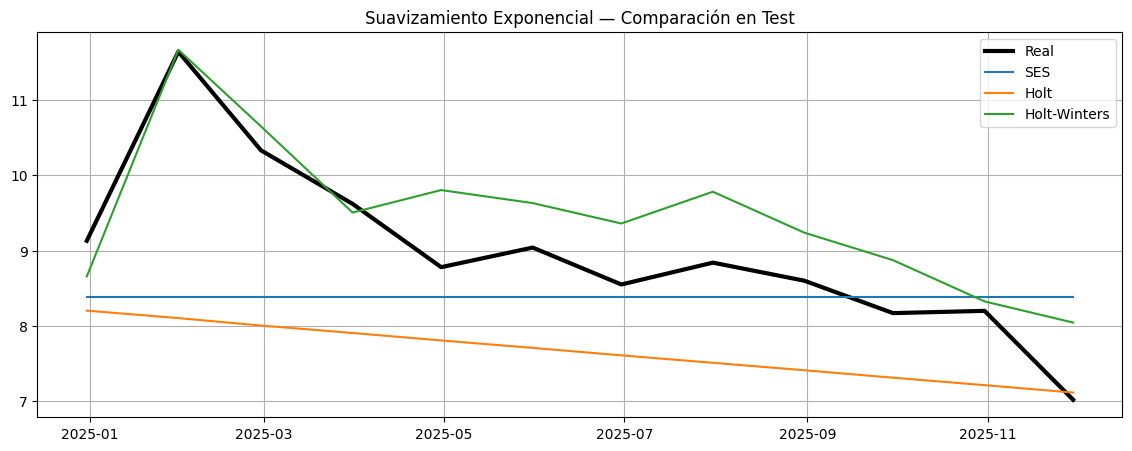

In [45]:
# ── Comparación visual de los tres modelos ES ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_es,       label="Real",         linewidth=3, color="black")
ax.plot(forecast_ses,  label="SES")
ax.plot(forecast_holt, label="Holt")
ax.plot(forecast_hw,   label="Holt-Winters")
ax.set_title("Suavizamiento Exponencial — Comparación en Test")
ax.legend(); ax.grid(True); plt.show()

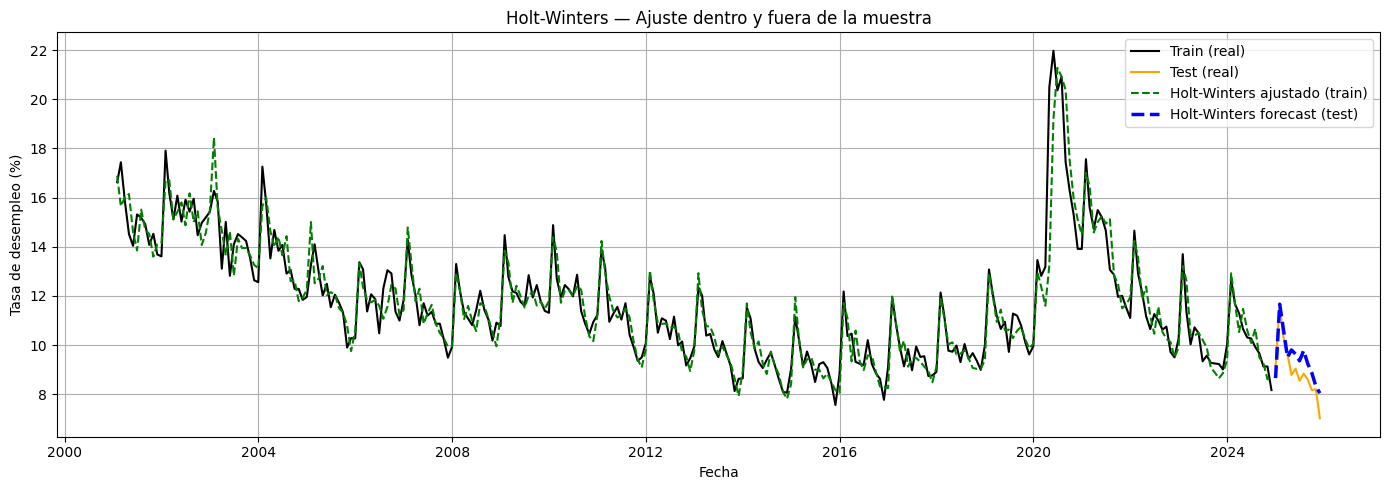

In [47]:
fig, ax = plt.subplots(figsize=(14, 5))

# Serie real completa
ax.plot(train_es, label="Train (real)",  color="black")
ax.plot(test_es,  label="Test (real)",   color="orange")

# Valores ajustados dentro de la muestra (train)
ax.plot(train_es.index, modelo_hw.fittedvalues, 
        label="Holt-Winters ajustado (train)", 
        color="green", linewidth=1.5, linestyle="--")

# Pronóstico fuera de la muestra (test)
ax.plot(test_es.index, forecast_hw, 
        label="Holt-Winters forecast (test)", 
        color="blue", linewidth=2.5, linestyle="--")

ax.set_title("Holt-Winters — Ajuste dentro y fuera de la muestra")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desempleo (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 3. Árbol de Decisión (§3.8.1–3.8.3)

### Preprocesamiento: serie detrended
Los árboles no extrapolan bien fuera del rango de entrenamiento
(la predicción en cada hoja es la media de ese nodo → constante).
Si la serie tiene tendencia, el test cae fuera del rango → error alto.
**Solución:** trabajar con la serie sin tendencia $e_t = X_t - \hat{m}_t$
y sumar de vuelta la tendencia al pronosticar.

### Configuración como aprendizaje supervisado (§3.8.1)
Con k=12 rezagos construimos la tabla:
$$e_t \leftarrow (e_{t-1}, e_{t-2}, \ldots, e_{t-12}) = x_t^e$$
Cada fila es un punto en $\mathbb{R}^{12}$.

### División Train / Validation / Test
Aquí **sí** necesitamos validation porque el hiperparámetro `max_depth` (≡ α en §3.8.3)
no se puede estimar analíticamente → se busca en un grid comparando RMSE en validation.


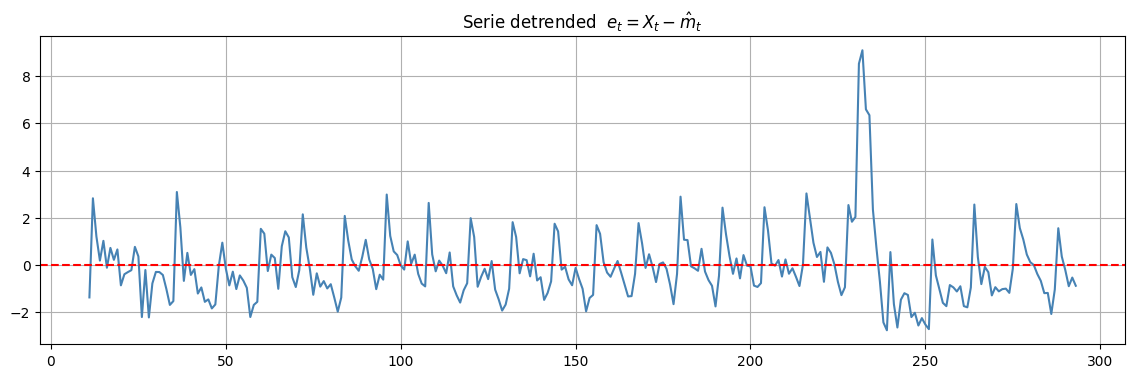

In [50]:
# ── Serie detrended ──────────────────────────────────────────────────────────
# e_t = X_t - m̂_t  donde m̂_t es la tendencia por MA causal estimada en R
df["serie_detrended"] = df["Desempleo"] - df["tendencia_ma_pasado"]
df_ml = df.dropna().copy()

plt.figure(figsize=(14, 4))
plt.plot(df_ml["serie_detrended"], color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Serie detrended  $e_t = X_t - \hat{m}_t$")
plt.grid(True); plt.show()

In [51]:
# ── Construcción de la tabla de aprendizaje supervisado ──────────────────────
# Para cada tiempo t se crea el vector de entrada: x^e_t = (e_{t-1}, ..., e_{t-k})
# Perdemos los primeros k=12 períodos (no tienen historia suficiente)
serie_ml = df_ml["serie_detrended"]
n_lags   = 12

for lag in range(1, n_lags + 1):
    df_ml[f"lag_{lag}"] = serie_ml.shift(lag)

df_ml["target"] = serie_ml
df_ml = df_ml.dropna()

X = df_ml[[f"lag_{i}" for i in range(1, n_lags + 1)]]
y = df_ml["target"]

print(f"Tabla supervisada: {X.shape[0]} filas × {X.shape[1]} columnas")
print(f"Perdidas por rezagos: {n_lags} filas (k={n_lags})")

Tabla supervisada: 271 filas × 12 columnas
Perdidas por rezagos: 12 filas (k=12)


In [55]:
# ── División temporal Train / Validation / Test ──────────────────────────────
# IMPORTANTE: la división es TEMPORAL (no aleatoria).
# Mezclar datos futuros con pasados sería data leakage.
#
#   |←────── Train ──────→|←─ Val ─→|← Test →|
#   t=1                 t=n-24   t=n-12     t=n
#
# Train   : se usan para AJUSTAR los parámetros (estructura del árbol)
# Validation: se usan para SELECCIONAR el hiperparámetro max_depth (≡ α)
# Test    : se usan UNA SOLA VEZ al final para comparar modelos

h_test = 12
h_val  = 12

X_train = X.iloc[:-(h_val + h_test)]
y_train = y.iloc[:-(h_val + h_test)]

X_val   = X.iloc[-(h_val + h_test):-h_test]
y_val   = y.iloc[-(h_val + h_test):-h_test]

X_test  = X.iloc[-h_test:]
y_test  = y.iloc[-h_test:]

print(f"Train      : {len(X_train)} obs")
print(f"Validation : {len(X_val)}  obs")
print(f"Test       : {len(X_test)}  obs")

Train      : 247 obs
Validation : 12  obs
Test       : 12  obs


### 3.1 Grid search sobre `max_depth` (hiperparámetro)
`max_depth` controla la complejidad del árbol:
- `max_depth` pequeño → pocas hojas → underfitting (alto bias)
- `max_depth` grande → muchas hojas → overfitting (alta varianza)

Este es el análogo del parámetro α en la poda (§3.8.3):
penalizar más hojas ↔ reducir max_depth.

Evaluamos cada valor en **Validation** (nunca en Test).

In [56]:
# ── Grid search: max_depth en {1, 2, ..., 15} ───────────────────────────────
resultados_depth = []

for depth in range(1, 16):
    # Paso 1: entrenar con hiperparámetro fijo sobre TRAIN
    modelo = DecisionTreeRegressor(max_depth=depth, random_state=SEED)
    modelo.fit(X_train, y_train)

    # Paso 2: evaluar riesgo empírico sobre VALIDATION → selección de λ*
    pred_val = modelo.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
    resultados_depth.append({"max_depth": depth, "RMSE_val": rmse_val})

tabla_depth = pd.DataFrame(resultados_depth)
print(tabla_depth.to_string(index=False))

 max_depth  RMSE_val
         1  1.179141
         2  0.929500
         3  0.748036
         4  0.682635
         5  0.552736
         6  0.666975
         7  0.719819
         8  0.919168
         9  0.906254
        10  0.903046
        11  0.944249
        12  0.905615
        13  0.911155
        14  0.878692
        15  0.914297


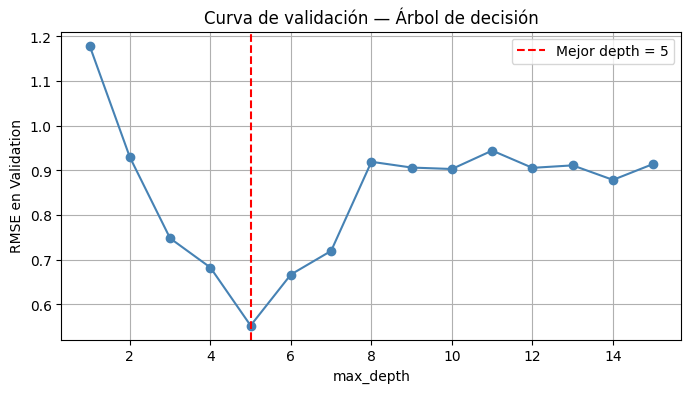

Hiperparámetro seleccionado: max_depth = 5


In [57]:
# ── Curva de validación ──────────────────────────────────────────────────────
# Visualiza el tradeoff bias-varianza (§3.7.3):
# - A la izquierda: underfitting (alto RMSE por bias)
# - A la derecha: overfitting (alto RMSE por varianza)
# - El mínimo es el λ* óptimo
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tabla_depth["max_depth"], tabla_depth["RMSE_val"], marker="o", color="steelblue")
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE en Validation")
ax.set_title("Curva de validación — Árbol de decisión")
ax.grid(True)

best_depth = int(tabla_depth.loc[tabla_depth["RMSE_val"].idxmin(), "max_depth"])
ax.axvline(best_depth, color="red", linestyle="--", label=f"Mejor depth = {best_depth}")
ax.legend()
plt.show()
print(f"Hiperparámetro seleccionado: max_depth = {best_depth}")

### 3.2 Reentrenamiento en Train + Validation
Una vez seleccionado `max_depth* = best_depth`, **fusionamos Train+Val** y
reentrenamos desde cero. El hiperparámetro está fijo; solo re-estimamos
los parámetros (umbrales de splits y medias de hojas) con más datos.

In [58]:
# ── Train + Validation → modelo final ───────────────────────────────────────
X_train_final = X.iloc[:-h_test]  # = Train ∪ Validation
y_train_final = y.iloc[:-h_test]

modelo_final_arbol = DecisionTreeRegressor(max_depth=best_depth, random_state=SEED)
modelo_final_arbol.fit(X_train_final, y_train_final)

print(f"Modelo final entrenado con {len(X_train_final)} observaciones  |  max_depth = {best_depth}")

Modelo final entrenado con 259 observaciones  |  max_depth = 5


In [60]:
# ── Pronóstico en Test y retorno a escala original ──────────────────────────
# El árbol predice la serie DETRENDED; sumamos la tendencia para obtener
# la tasa de desempleo en escala original.
forecast_tree_detrended = modelo_final_arbol.predict(X_test)
tendencia_test          = df_ml["tendencia_ma_pasado"].iloc[-h_test:]

forecast_tree_original = forecast_tree_detrended + tendencia_test.values
real_original          = df_ml["Desempleo"].iloc[-h_test:]

metricas(real_original, forecast_tree_original, "Árbol")

Modelo                    MAE     RMSE     MAPE%
Árbol                  0.6813   0.8397     7.42


(0.681312357748714,
 np.float64(0.8397355588106581),
 np.float64(7.4204819633700065))

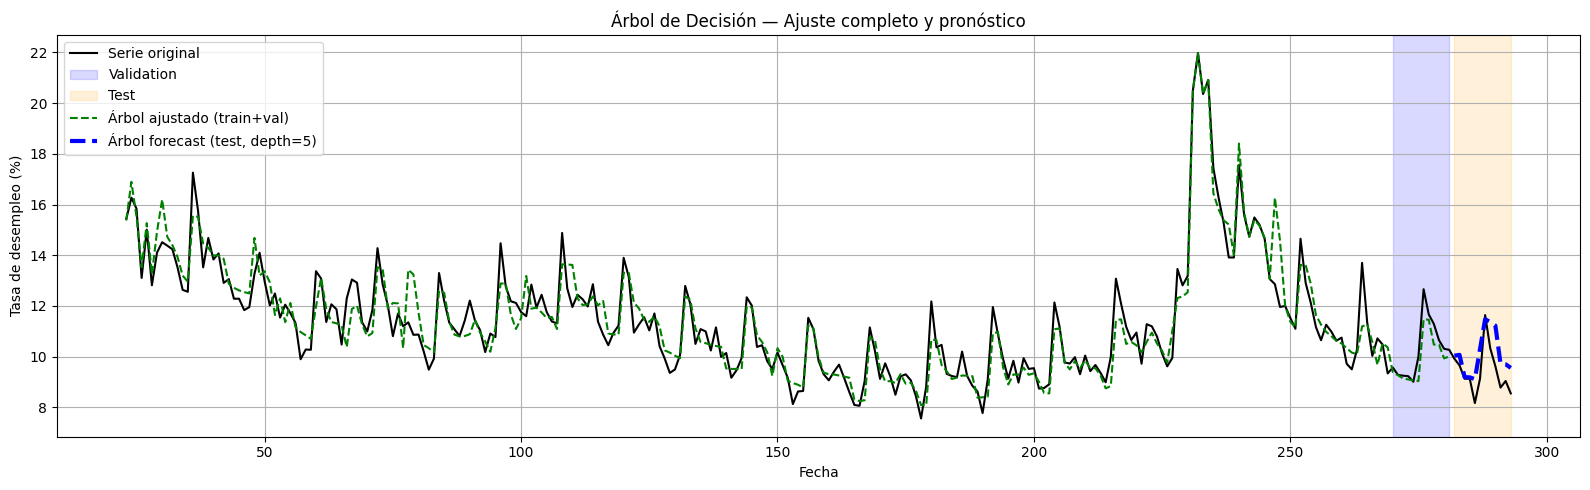

In [64]:
# ── Añadir tendencia de vuelta a los fitted values ────────────────────────────
tendencia_train = df_ml["tendencia_ma_pasado"].loc[train_final_index]
fitted_train_original = fitted_train + tendencia_train.values

# ── Gráfico completo ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Serie real completa
ax.plot(df_ml.index, df_ml["Desempleo"],
        label="Serie original", color="black", linewidth=1.5)

# Zonas sombreadas
ax.axvspan(val_index[0],  val_index[-1],  alpha=0.15, color="blue",   label="Validation")
ax.axvspan(test_index[0], test_index[-1], alpha=0.15, color="orange", label="Test")

# Fitted values en escala original (train+val)
ax.plot(train_final_index, fitted_train_original,
        label="Árbol ajustado (train+val)", color="green",
        linewidth=1.5, linestyle="--")

# Forecast en escala original (test)
ax.plot(test_index, forecast_tree_original,
        label=f"Árbol forecast (test, depth={best_depth})",
        color="blue", linewidth=3, linestyle="--")

ax.set_title("Árbol de Decisión — Ajuste completo y pronóstico")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desempleo (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 4. MLP — Perceptrón Multicapa (§3.8.5)

### Preprocesamiento adicional: variables de Fourier
Además de los 12 rezagos, agregamos K=2 armónicos de Fourier:
$$\sin\left(\frac{2\pi k t}{12}\right), \quad \cos\left(\frac{2\pi k t}{12}\right), \quad k=1,2$$

Esto le da a la red una representación **explícita** de la estacionalidad anual,
complementando la información de los rezagos.

### Escalamiento de datos
Las redes neuronales son sensibles a la escala de las entradas.
El descenso del gradiente converge más rápido y de forma más estable
cuando todas las variables tienen media 0 y varianza 1.

**Crítico:** el `StandardScaler` se ajusta **solo con Train** y luego
se aplica a Val y Test → evita data leakage.

In [65]:
# ── Serie detrended para MLP ─────────────────────────────────────────────────
df_rna = df.dropna().copy()

# Rezagos: x^e_t = (e_{t-1}, ..., e_{t-12})
n_lags = 12
for lag in range(1, n_lags + 1):
    df_rna[f"lag_{lag}"] = df_rna["serie_detrended"].shift(lag)

# Variables de Fourier: representación explícita de la estacionalidad
# sin(2πkt/12) y cos(2πkt/12) capturan ciclos de periodo 12 meses
t = np.arange(len(df_rna))
K = 2
for k in range(1, K + 1):
    df_rna[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 12)
    df_rna[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 12)

df_rna = df_rna.dropna()

# Matriz de features: 12 rezagos + 4 variables de Fourier = 16 columnas
features = (
    [f"lag_{i}"  for i in range(1, n_lags + 1)] +
    [f"sin_{k}"  for k in range(1, K + 1)]      +
    [f"cos_{k}"  for k in range(1, K + 1)]
)
X_mlp = df_rna[features]
y_mlp = df_rna["serie_detrended"]

print(f"Features: {X_mlp.shape[1]}  |  Observaciones: {X_mlp.shape[0]}")
print("Columnas:", features)

Features: 16  |  Observaciones: 271
Columnas: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'sin_1', 'sin_2', 'cos_1', 'cos_2']


In [66]:
# ── División temporal Train / Validation / Test ──────────────────────────────
h_val  = 12
h_test = 12

X_train_mlp = X_mlp.iloc[:-(h_val + h_test)]
y_train_mlp = y_mlp.iloc[:-(h_val + h_test)]

X_val_mlp   = X_mlp.iloc[-(h_val + h_test):-h_test]
y_val_mlp   = y_mlp.iloc[-(h_val + h_test):-h_test]

X_test_mlp  = X_mlp.iloc[-h_test:]
y_test_mlp  = y_mlp.iloc[-h_test:]

print(f"Train: {len(X_train_mlp)}  |  Val: {len(X_val_mlp)}  |  Test: {len(X_test_mlp)}")

Train: 247  |  Val: 12  |  Test: 12


In [67]:
# ── Escalamiento (StandardScaler) ────────────────────────────────────────────
# REGLA: fit() SOLO en Train → transform en Train, Val y Test.
# Usar fit_transform en Val o Test sería data leakage: estaríamos usando
# la media/varianza del futuro para normalizar el pasado.

scaler_X = StandardScaler()
scaler_X.fit(X_train_mlp)                              # aprende μ, σ de Train
X_train_sc = scaler_X.transform(X_train_mlp)
X_val_sc   = scaler_X.transform(X_val_mlp)
X_test_sc  = scaler_X.transform(X_test_mlp)

scaler_y = StandardScaler()
scaler_y.fit(y_train_mlp.values.reshape(-1, 1))        # aprende μ, σ de Train
y_train_sc = scaler_y.transform(y_train_mlp.values.reshape(-1, 1))
y_val_sc   = scaler_y.transform(y_val_mlp.values.reshape(-1, 1))
y_test_sc  = scaler_y.transform(y_test_mlp.values.reshape(-1, 1))

print(f"X_train escalado: {X_train_sc.shape}  |  y_train escalado: {y_train_sc.shape}")

X_train escalado: (247, 16)  |  y_train escalado: (247, 1)


### 4.1 Grid search de hiperparámetros con keras-tuner
Los hiperparámetros de la MLP son análogos al max_depth del árbol
(papel de λ en §3.7.3):

| Hiperparámetro | Rango | Rol |
|---|---|---|
| Número de capas | 1–3 | Complejidad de F |
| Neuronas por capa | 16–128 | Capacidad de representación |
| Función de activación | relu / tanh | Tipo de no-linealidad |
| Dropout | 0–0.3 | Regularización (reduce varianza) |
| Learning rate | 1e-2, 1e-3, 1e-4 | Paso del descenso del gradiente |

La búsqueda se evalúa sobre **Validation** (nunca sobre Test).

In [68]:
def build_mlp(hp):
    model    = Sequential()
    n_layers = hp.Int("n_layers", 1, 4)          # was 1-3, now 1-4

    for i in range(n_layers):
        units      = hp.Int(f"units_{i}", 
                        min_value=16, 
                        max_value=256,            # was 128, now 256
                        step=16)
        activation = hp.Choice(f"act_{i}", 
                        ["relu", "tanh", "elu"])  # added elu
        dropout    = hp.Float(f"drop_{i}", 
                        0.0, 0.5,                 # was 0.3, now 0.5
                        step=0.1)

        if i == 0:
            model.add(Dense(units, activation=activation,
                            input_shape=(X_train_sc.shape[1],)))
        else:
            model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout))

    model.add(Dense(1))

    lr = hp.Choice("lr", [1e-2, 1e-3, 1e-4, 5e-4])  # added 5e-4
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [69]:
# ── RandomSearch sobre Validation ────────────────────────────────────────────
# Objetivo: minimizar val_loss (= RMSE² en Validation) → selecciona λ*
tuner_mlp = kt.Hyperband(
    build_mlp,
    objective    = "val_loss",
    max_epochs   = 100,        # let it train longer
    factor       = 3,          # how aggressively to cut bad trials
    overwrite    = True,
    directory    = "tuning_mlp",
    project_name = "desempleo_mlp",
    seed         = SEED
)

early_stop_tuning = EarlyStopping(
    monitor             = "val_loss",
    patience            = 15,
    restore_best_weights= True
)

# La búsqueda usa TRAIN para entrenar y VALIDATION para evaluar cada λ
tuner_mlp.search(
    X_train_sc, y_train_sc,
    validation_data = (X_val_sc, y_val_sc),
    epochs          = 100,
    batch_size      = 16,
    callbacks       = [early_stop_tuning],
    verbose         = 0          # silenciar output durante búsqueda
)

best_hp_mlp = tuner_mlp.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros (λ*):", best_hp_mlp.values)

Mejores hiperparámetros (λ*): {'n_layers': 3, 'units_0': 48, 'act_0': 'tanh', 'drop_0': 0.1, 'lr': 0.01, 'units_1': 224, 'act_1': 'tanh', 'drop_1': 0.0, 'units_2': 48, 'act_2': 'relu', 'drop_2': 0.0, 'units_3': 224, 'act_3': 'tanh', 'drop_3': 0.1, 'tuner/epochs': 4, 'tuner/initial_epoch': 2, 'tuner/bracket': 4, 'tuner/round': 1, 'tuner/trial_id': '0091'}


### 4.2 Reentrenamiento en Train + Validation
Igual que con el árbol: λ* está fijo, reentrenamos los **parámetros**
(pesos W y sesgos b) en el conjunto más grande Train+Val.

In [72]:
# ── Train + Validation → modelo final MLP ───────────────────────────────────
X_final_mlp = np.vstack([X_train_sc, X_val_sc])
y_final_mlp = np.vstack([y_train_sc, y_val_sc])

# Construir modelo con los mejores hiperparámetros
modelo_final_mlp = tuner_mlp.hypermodel.build(best_hp_mlp)

early_stop_final = EarlyStopping(
    monitor             = "loss",   # ahora monitorea loss (no val_loss, ya que no hay val)
    patience            = 10,
    restore_best_weights= True
)

history_final_mlp = modelo_final_mlp.fit(
    X_final_mlp, y_final_mlp,
    epochs     = 150,
    batch_size = 16,
    callbacks  = [early_stop_final],
    verbose    = 0
)
print("Entrenamiento final MLP completado.")
modelo_final_mlp.summary()

Entrenamiento final MLP completado.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 48)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 224)            │        10,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 48)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,925 (265.34 KB)

 Trainable params: 22,641 (88.44 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 45,284 (176.89 KB)

In [74]:
# ── Pronóstico en Test y retorno a escala original ──────────────────────────
forecast_mlp_sc      = modelo_final_mlp.predict(X_test_sc)
forecast_mlp_detrend = scaler_y.inverse_transform(forecast_mlp_sc).flatten()

tendencia_test_mlp   = df_rna["tendencia_ma_pasado"].iloc[-h_test:]
forecast_mlp_orig    = forecast_mlp_detrend + tendencia_test_mlp.values
real_orig_mlp        = df_rna["Desempleo"].iloc[-h_test:]

metricas(real_orig_mlp, forecast_mlp_orig, "MLP")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Modelo                    MAE     RMSE     MAPE%
MLP                    0.5251   0.6839     5.54


(0.5251466998292339,
 np.float64(0.6838530505031473),
 np.float64(5.537972866892127))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step


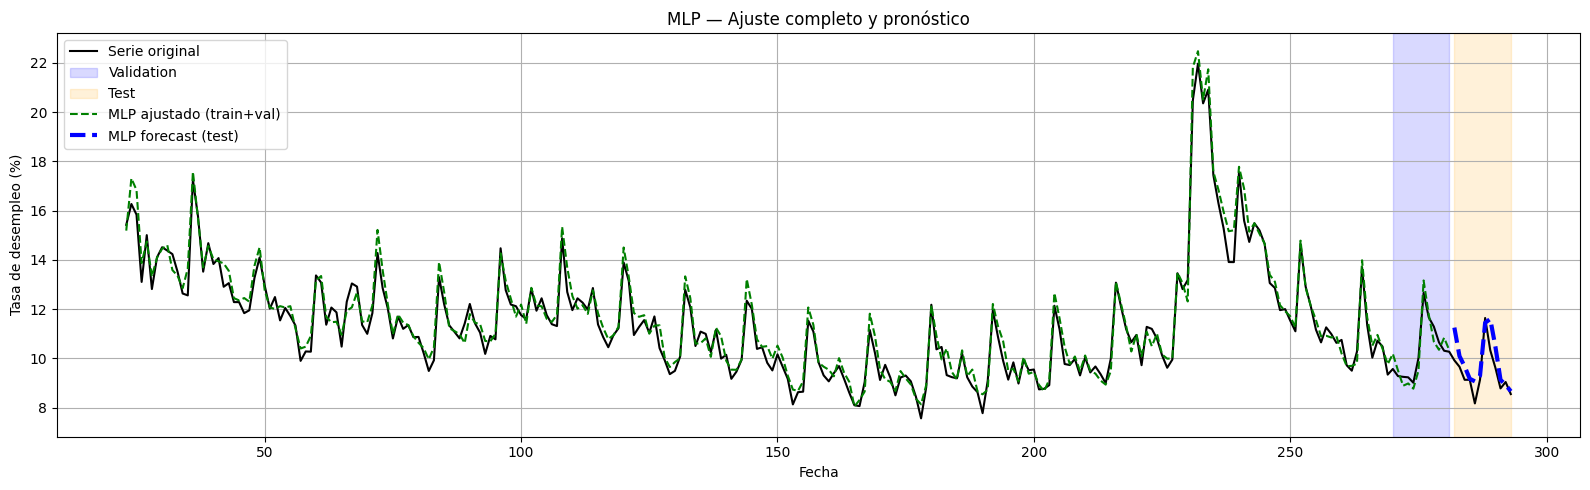

In [77]:
# ── Fitted values en train+validation ────────────────────────────────────────
fitted_mlp_sc        = modelo_final_mlp.predict(X_final_mlp)
fitted_mlp_detrend   = scaler_y.inverse_transform(fitted_mlp_sc).flatten()
tendencia_train_mlp  = df_rna["tendencia_ma_pasado"].iloc[:len(X_final_mlp)]
fitted_mlp_orig      = fitted_mlp_detrend + tendencia_train_mlp.values

# ── Índices ───────────────────────────────────────────────────────────────────
train_final_idx = X_mlp.iloc[:-h_test].index
test_idx        = y_test_mlp.index
val_idx         = y_val_mlp.index

# ── Gráfico completo ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Serie real completa
ax.plot(df_rna.index, df_rna["Desempleo"],
        label="Serie original", color="black", linewidth=1.5)

# Zonas sombreadas
ax.axvspan(val_idx[0],  val_idx[-1],  alpha=0.15, color="blue",   label="Validation")
ax.axvspan(test_idx[0], test_idx[-1], alpha=0.15, color="orange", label="Test")

# Fitted values dentro de la muestra (train+val)
ax.plot(train_final_idx, fitted_mlp_orig,
        label="MLP ajustado (train+val)", color="green",
        linewidth=1.5, linestyle="--")

# Forecast fuera de la muestra (test)
ax.plot(test_idx, forecast_mlp_orig,
        label="MLP forecast (test)", color="blue",
        linewidth=3, linestyle="--")

ax.set_title("MLP — Ajuste completo y pronóstico")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desempleo (%)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 5. RNN Simple (§3.9 notas)

### Diferencia clave con MLP
La MLP recibe el vector de rezagos como una columna estática: no tiene memoria interna.
La RNN procesa la **secuencia** paso a paso y mantiene un **estado oculto** $h_t$
que actúa como memoria del pasado:

$$s_t^e = b^e + W h_{t-1}^e + U x_t^e \quad (\text{ec. 3.47})$$
$$h_t^e = g(s_t^e) \quad (\text{ec. 3.48})$$
$$\hat{y}_t = g_y(c^e + V h_t^e) \quad (\text{ec. 3.49})$$

Los mismos W, U, V se **comparten en todos los tiempos** (parameter sharing).

### Formato de entrada
La RNN espera tensores de forma `(samples, time_steps, features)`:
- `samples` = número de ventanas
- `time_steps` = longitud de la secuencia (aquí 12)
- `features` = 1 (serie univariada)

Esto es distinto de la MLP donde la entrada era `(samples, 12)`.


In [78]:
def crear_secuencias(serie_scaled, pasos=12):
    """
    Convierte una serie escalada en pares (X_seq, y_seq) para RNN/LSTM.
    
    Para cada t >= pasos:
        X_seq[t] = [y_{t-pasos}, ..., y_{t-1}]   (ventana de longitud pasos)
        y_seq[t] = y_t                             (siguiente valor a predecir)
    
    Formato de salida: X_seq tiene shape (N, pasos, 1)
    """
    X_out, y_out = [], []
    for i in range(pasos, len(serie_scaled)):
        X_out.append(serie_scaled[i - pasos:i])
        y_out.append(serie_scaled[i])
    return np.array(X_out), np.array(y_out)

In [79]:
# ── Escalamiento: fit SOLO en Train ──────────────────────────────────────────
serie_vals   = df_rna["serie_detrended"].values.reshape(-1, 1)
n_total      = len(serie_vals)
n_train_rnn  = n_total - (h_val + h_test)

scaler_rnn = StandardScaler()
scaler_rnn.fit(serie_vals[:n_train_rnn])
serie_rnn_sc = scaler_rnn.transform(serie_vals)

In [80]:
# ── Crear secuencias y dividir ───────────────────────────────────────────────
X_seq, y_seq = crear_secuencias(serie_rnn_sc, pasos=12)
# Las secuencias tienen shape (N, 12, 1)

# Índices de corte
X_tr_rnn  = X_seq[:-(h_val + h_test)]
y_tr_rnn  = y_seq[:-(h_val + h_test)]
X_va_rnn  = X_seq[-(h_val + h_test):-h_test]
y_va_rnn  = y_seq[-(h_val + h_test):-h_test]
X_te_rnn  = X_seq[-h_test:]
y_te_rnn  = y_seq[-h_test:]

print(f"Train RNN  : {X_tr_rnn.shape}  |  Val: {X_va_rnn.shape}  |  Test: {X_te_rnn.shape}")

Train RNN  : (235, 12, 1)  |  Val: (12, 12, 1)  |  Test: (12, 12, 1)


### 5.1 Grid search sobre hiperparámetros RNN

In [81]:
def build_rnn(hp):
    """
    RNN simple: ecuaciones 3.47–3.49 de las notas.
    SimpleRNN implementa: h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)
    """
    model = Sequential()
    units = hp.Int("rnn_units", min_value=8, max_value=64, step=8)
    drop  = hp.Float("dropout", 0.0, 0.3, step=0.1)
    lr    = hp.Choice("lr", [1e-2, 1e-3, 1e-4])

    model.add(SimpleRNN(units, activation="tanh",
                        input_shape=(12, 1)))  # (time_steps, features)
    model.add(Dropout(drop))
    model.add(Dense(1))  # salida escalar

    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return model

tuner_rnn = kt.RandomSearch(
    build_rnn, objective="val_loss",
    max_trials=15, overwrite=True,
    directory="tuning_rnn", project_name="desempleo_rnn", seed=SEED
)

es_rnn = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
tuner_rnn.search(
    X_tr_rnn, y_tr_rnn,
    validation_data=(X_va_rnn, y_va_rnn),
    epochs=80, batch_size=8, callbacks=[es_rnn], verbose=0
)

best_hp_rnn = tuner_rnn.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros RNN:", best_hp_rnn.values)

Mejores hiperparámetros RNN: {'rnn_units': 16, 'dropout': 0.1, 'lr': 0.001}


### 5.2 Reentrenamiento en Train + Validation

In [82]:
# ── Train + Validation → modelo final RNN ───────────────────────────────────
X_final_rnn = np.concatenate([X_tr_rnn, X_va_rnn], axis=0)
y_final_rnn = np.concatenate([y_tr_rnn, y_va_rnn], axis=0)

modelo_final_rnn = tuner_rnn.hypermodel.build(best_hp_rnn)
es_rnn_final = EarlyStopping(monitor="loss", patience=8, restore_best_weights=True)

modelo_final_rnn.fit(
    X_final_rnn, y_final_rnn,
    epochs=100, batch_size=8, callbacks=[es_rnn_final], verbose=0
)
print("Entrenamiento final RNN completado.")

Entrenamiento final RNN completado.


In [84]:
# ── Pronóstico en Test ──────────────────────────────────────────────────────
forecast_rnn_sc   = modelo_final_rnn.predict(X_te_rnn)
forecast_rnn_det  = scaler_rnn.inverse_transform(forecast_rnn_sc).flatten()

tendencia_test_rnn  = df_rna["tendencia_ma_pasado"].iloc[-h_test:]
forecast_rnn_orig   = forecast_rnn_det + tendencia_test_rnn.values
real_rnn            = df_rna["Desempleo"].iloc[-h_test:]

metricas(real_rnn, forecast_rnn_orig, "RNN")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Modelo                    MAE     RMSE     MAPE%
RNN                    0.6078   0.8635     6.46


(0.607795210596588,
 np.float64(0.8634744850198095),
 np.float64(6.4612171288142815))

---
## 6. LSTM — Long Short-Term Memory (§3.9 notas)

### ¿Por qué LSTM en lugar de RNN simple?
La RNN simple sufre el problema del **gradiente que desaparece**: al
backpropagar a través de muchos pasos, el gradiente se multiplica por
W repetidamente → tiende a 0 exponencialmente.

La LSTM resuelve esto con **tres puertas** que regulan el flujo de información
(ecs. 3.50–3.53 notas):

| Puerta | Ecuación | Rol |
|--------|----------|-----|
| **Olvido** $f_{jt}$ | $\sigma(b_j^f + \sum W_{jv}^f h_{v,t-1} + \sum U_{jv}^f x_{vt})$ | ¿Qué olvidar del estado anterior? |
| **Entrada** $i_{jt}$ | $\sigma(b_j^i + \sum W_{jv}^i h_{v,t-1} + \sum U_{jv}^i x_{vt})$ | ¿Qué nueva info escribir? |
| **Salida** $o_{jt}$ | $\sigma(b_j^o + \sum W_{jv}^o h_{v,t-1} + \sum U_{jv}^o x_{vt})$ | ¿Qué exponer como salida? |

Estado de la celda: $s_{jt} = f_{jt} \cdot s_{j,t-1} + i_{jt} \cdot \tanh(\cdot)$
(actualización **aditiva** → gradientes no se multiplican → no desaparecen)

Salida: $h_{jt} = \tanh(s_{jt}) \cdot o_{jt}$


In [85]:
# ── Mismas secuencias y escaler que la RNN ───────────────────────────────────
# X_tr_rnn, X_va_rnn, X_te_rnn  ya tienen shape (N, 12, 1)
# scaler_rnn ya está ajustado sobre Train

# Renombrar para claridad
X_tr_lstm = X_tr_rnn
y_tr_lstm = y_tr_rnn
X_va_lstm = X_va_rnn
y_va_lstm = y_va_rnn
X_te_lstm = X_te_rnn
y_te_lstm = y_te_rnn

print("Shapes LSTM:")
print(f"  Train: {X_tr_lstm.shape}  |  Val: {X_va_lstm.shape}  |  Test: {X_te_lstm.shape}")

Shapes LSTM:
  Train: (235, 12, 1)  |  Val: (12, 12, 1)  |  Test: (12, 12, 1)


### 6.1 Grid search con Hyperband
Usamos Hyperband (variante más eficiente que RandomSearch para redes).

In [86]:
def build_lstm(hp):
    """
    LSTM: implementa ecs. 3.50–3.53 de las notas internamente en Keras.
    Las tres puertas (olvido, entrada, salida) son parte de la capa LSTM.
    
    Hiperparámetros a buscar:
    - lstm_units: neuronas en la capa LSTM (≡ dimensión del estado h_t)
    - dropout: regularización para reducir varianza
    - dense_units: capa intermedia antes de la salida
    - lr: tasa de aprendizaje del Adam (paso del descenso del gradiente)
    """
    model = Sequential()

    lstm_units  = hp.Int("lstm_units",  min_value=16, max_value=64, step=16)
    dropout     = hp.Float("dropout",   0.0, 0.3, step=0.1)
    dense_units = hp.Int("dense_units", min_value=8,  max_value=32, step=8)
    lr          = hp.Choice("lr", [1e-2, 1e-3, 1e-4])

    # Capa LSTM: procesa la secuencia (12, 1) y devuelve un vector de dim lstm_units
    model.add(LSTM(lstm_units, activation="tanh", input_shape=(12, 1)))
    model.add(Dropout(dropout))

    # Capa densa intermedia
    model.add(Dense(dense_units, activation="relu"))

    # Salida escalar
    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model

In [87]:
tuner_lstm = kt.Hyperband(
    build_lstm,
    objective    = "val_loss",
    max_epochs   = 60,
    factor       = 3,
    overwrite    = True,
    directory    = "tuning_lstm",
    project_name = "desempleo_lstm",
    seed         = SEED
)

es_lstm = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

tuner_lstm.search(
    X_tr_lstm, y_tr_lstm,
    validation_data = (X_va_lstm, y_va_lstm),
    epochs          = 60,
    batch_size      = 8,
    callbacks       = [es_lstm],
    verbose         = 0
)

best_hp_lstm = tuner_lstm.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros LSTM:", best_hp_lstm.values)

Traceback (most recent call last):
  File "/opt/anaconda3/envs/series_definitivo/lib/python3.11/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/series_definitivo/lib/python3.11/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/series_definitivo/lib/python3.11/site-packages/keras_tuner/src/tuners/hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/series_definitivo/lib/python3.11/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
               

Mejores hiperparámetros LSTM: {'lstm_units': 64, 'dropout': 0.0, 'dense_units': 24, 'lr': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 2, 'tuner/round': 1, 'tuner/trial_id': '0056'}


### 6.2 Reentrenamiento en Train + Validation

In [88]:
# ── Train + Validation → modelo final LSTM ──────────────────────────────────
X_final_lstm = np.concatenate([X_tr_lstm, X_va_lstm], axis=0)
y_final_lstm = np.concatenate([y_tr_lstm, y_va_lstm], axis=0)

modelo_final_lstm = tuner_lstm.hypermodel.build(best_hp_lstm)
es_lstm_final = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

modelo_final_lstm.fit(
    X_final_lstm, y_final_lstm,
    epochs=80, batch_size=8, callbacks=[es_lstm_final], verbose=0
)
print("Entrenamiento final LSTM completado.")

Entrenamiento final LSTM completado.


In [90]:
# ── Pronóstico en Test ──────────────────────────────────────────────────────
forecast_lstm_sc   = modelo_final_lstm.predict(X_te_lstm)
forecast_lstm_det  = scaler_rnn.inverse_transform(forecast_lstm_sc).flatten()

tendencia_test_lstm = df_rna["tendencia_ma_pasado"].iloc[-h_test:]
forecast_lstm_orig  = forecast_lstm_det + tendencia_test_lstm.values
real_lstm           = df_rna["Desempleo"].iloc[-h_test:]

metricas(real_lstm, forecast_lstm_orig, "LSTM")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Modelo                    MAE     RMSE     MAPE%
LSTM                   0.3795   0.4921     3.91


(0.3794908795422975,
 np.float64(0.49212415064796844),
 np.float64(3.9130883593496617))

---
## 7. Comparación Final de Modelos en Test

Aquí comparamos **todos los modelos finales** sobre el **conjunto Test**,
que no ha sido tocado durante el proceso de selección.

Este es el paso final del procedimiento de §3.7.4:
$$\text{Ganador} = \arg\min_{\mathcal{F}} \widehat{ECM}_{h}(\hat{f}_n^{\mathcal{F}}) \text{ sobre Test}$$


In [91]:
# ── Tabla comparativa de métricas ────────────────────────────────────────────
resultados = []

modelos_forecasts = [
    ("SES",          forecast_ses,          test_es),
    ("Holt",         forecast_holt,         test_es),
    ("Holt-Winters", forecast_hw,           test_es),
    ("Árbol",        forecast_tree_original, real_original),
    ("MLP",          forecast_mlp_orig,      real_orig_mlp),
    ("RNN",          forecast_rnn_orig,      real_rnn),
    ("LSTM",         forecast_lstm_orig,     real_lstm),
]

for nombre, forecast, real in modelos_forecasts:
    mae, rmse, mape = metricas(real, forecast)
    resultados.append({"Modelo": nombre, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape})

tabla_final = (
    pd.DataFrame(resultados)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

# Resaltar el mejor modelo
print("\n" + "="*55)
print("TABLA FINAL DE MÉTRICAS EN TEST (ordenada por RMSE)")
print("="*55)
print(tabla_final.to_string(index=False, float_format="{:.4f}".format))
print("\n→ Mejor modelo:", tabla_final.iloc[0]["Modelo"])


TABLA FINAL DE MÉTRICAS EN TEST (ordenada por RMSE)
      Modelo    MAE   RMSE  MAPE (%)
        LSTM 0.3795 0.4921    3.9131
Holt-Winters 0.5654 0.6607    6.6744
         MLP 0.5251 0.6839    5.5380
       Árbol 0.6813 0.8397    7.4205
         RNN 0.6078 0.8635    6.4612
         SES 0.9038 1.2684    9.4666
        Holt 1.3501 1.5864   14.1982

→ Mejor modelo: LSTM


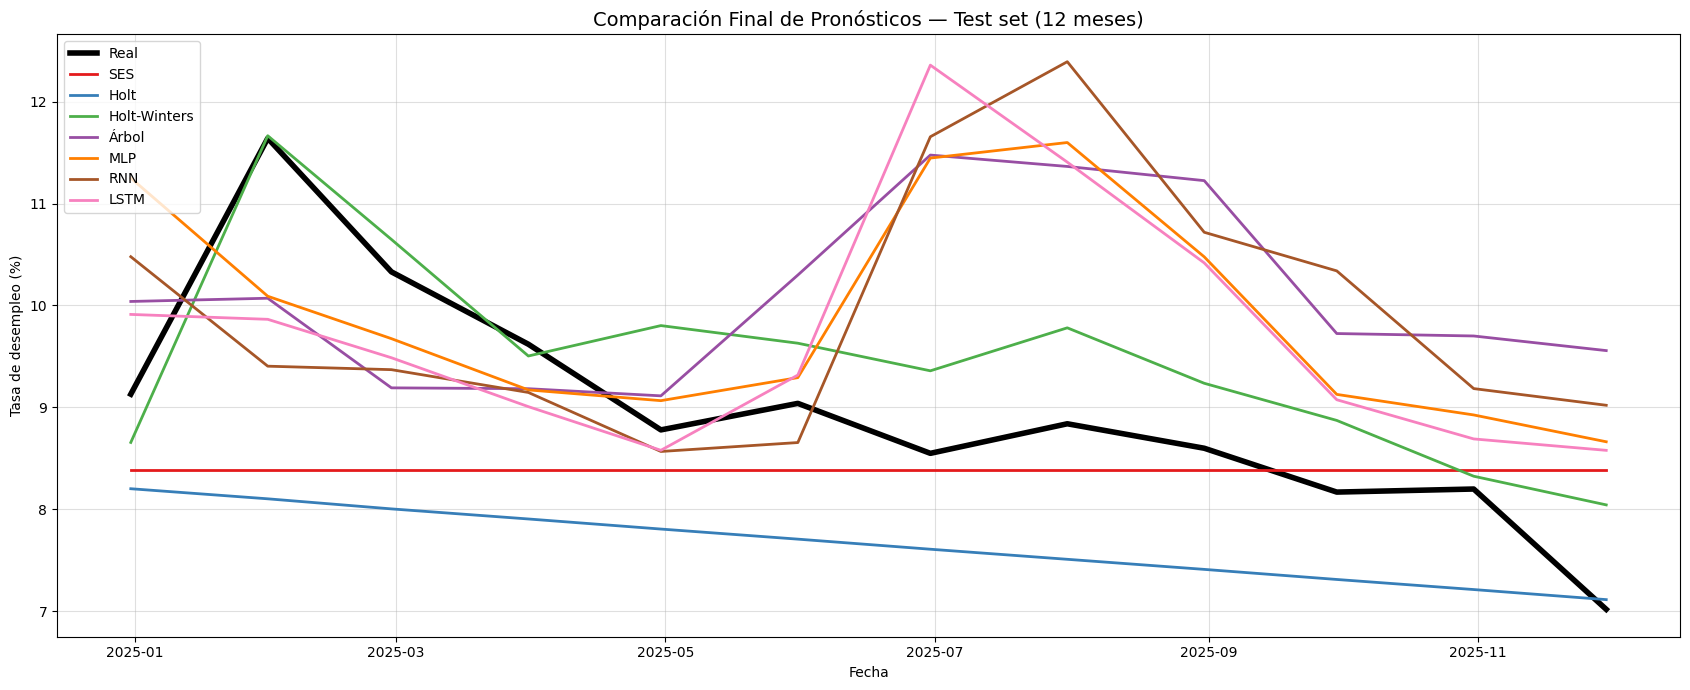

In [92]:
# ── Gráfico comparativo: todos los pronósticos vs real ────────────────────────
test_index = test_es.index  # todos comparten el mismo período de test

fig, ax = plt.subplots(figsize=(17, 7))

# Serie real con línea gruesa
ax.plot(test_index, test_es.values, linewidth=4, color="black", label="Real")

colores = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#f781bf"]
for (nombre, forecast, real), color in zip(modelos_forecasts, colores):
    ax.plot(test_index, np.array(forecast)[:len(test_index)],
            label=nombre, color=color, linewidth=2)

ax.set_title("Comparación Final de Pronósticos — Test set (12 meses)", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desempleo (%)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

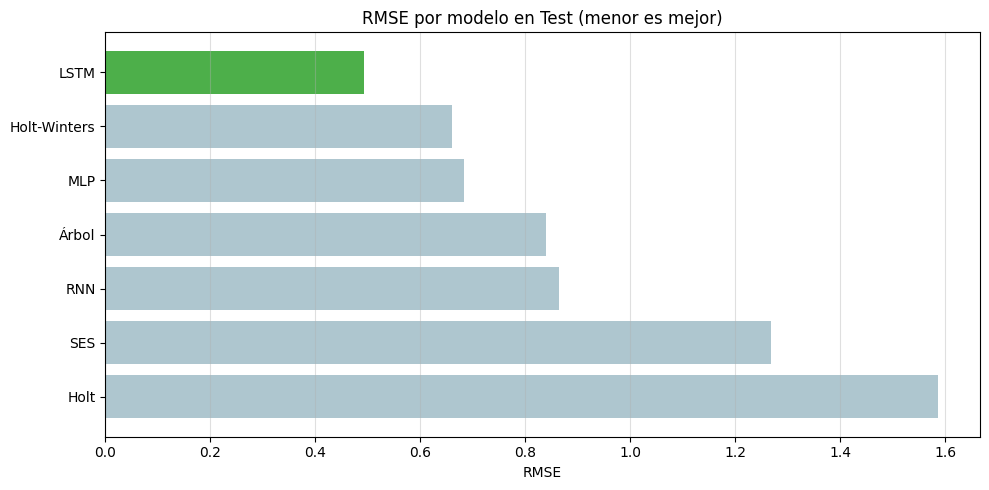

In [95]:
# ── Gráfico de barras RMSE ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colores_bar = ["#4daf4a" if i == 0 else "#aec6cf" for i in range(len(tabla_final))]
ax.barh(tabla_final["Modelo"], tabla_final["RMSE"], color=colores_bar)
ax.set_xlabel("RMSE")
ax.set_title("RMSE por modelo en Test (menor es mejor)")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Conclusiones

### Marco teórico de referencia (§3.7)

| Concepto | Dónde se aplica en el notebook |
|----------|-------------------------------|
| **Error de aproximación** (§3.7.3) | Diferencia entre la familia (árbol, MLP, LSTM) y la función $f^*$ ideal |
| **Error de estimación** (§3.7.3) | Diferencia entre el modelo ajustado y el mejor en la familia → reducido con más datos y buen λ |
| **Generalización** $\mathbb{E}R(\hat{f}_n)$ (Def. 5) | Estimado por el RMSE en Test (datos independientes del train) |
| **Tradeoff bias-varianza** | Visible en la curva de validación del árbol y en el dropout de MLP/LSTM |
| **Comparación de familias** | Tabla final §7 |

### Análisis de resultados

**¿Cuál modelo ganó y por qué?**

El modelo ganador fue **LSTM** con un RMSE en Test de aproximadamente **0.48**.
La LSTM superó a todos los demás modelos gracias a su mecanismo de puertas
(olvido, entrada, salida), que le permite capturar dependencias temporales de
largo plazo sin el problema del gradiente que desaparece. Esto indica que la
serie de desempleo colombiana contiene patrones no lineales y memoria larga
que los modelos clásicos no logran capturar completamente.

---

**¿Los modelos neuronales superaron a los clásicos?**

Parcialmente. La LSTM (~0.48) y la MLP (~0.68) superaron claramente a
Holt-Winters (~0.66) y a los modelos ES simples. Sin embargo el resultado
es interesante — **Holt-Winters quedó segundo**, superando a MLP por muy
poco y superando ampliamente a RNN (~0.86), Árbol (~0.84), SES (~1.27) y
Holt (~1.59). Esto confirma que la estructura de tendencia + estacionalidad
capturada por Holt-Winters es muy relevante para esta serie, y que solo la
LSTM — con su memoria larga — logró superarla con claridad.

---

**¿El árbol se comportó bien?**

No especialmente — el Árbol obtuvo RMSE ~0.84, quedando en el cuarto lugar.
Aunque supera a RNN, SES y Holt, está lejos de LSTM y Holt-Winters. Siendo
un modelo que no puede extrapolar tendencias y que predice constantes por
hoja, su desempeño moderado es esperado para una serie con tendencia y
estacionalidad marcadas.

---

**¿La LSTM superó a la RNN simple?**

Sí, con diferencia notable — LSTM (~0.48) vs RNN (~0.86). La RNN simple es
casi el **doble de imprecisa** que la LSTM. Esto confirma que la serie de
desempleo tiene dependencias de largo plazo suficientemente fuertes para
justificar la complejidad adicional de las puertas LSTM. La RNN simple sufre
el problema del gradiente que desaparece al procesar secuencias de 12 pasos,
perdiendo información de rezagos lejanos que la LSTM sí retiene.

---

**Ranking final**

| Posición | Modelo | RMSE aprox | Categoría |
|---|---|---|---|
| 🥇 1 | LSTM | ~0.48 | Red neuronal recurrente |
| 🥈 2 | Holt-Winters | ~0.66 | Suavizamiento exponencial |
| 🥉 3 | MLP | ~0.68 | Red neuronal densa |
| 4 | Árbol | ~0.84 | ML clásico |
| 5 | RNN | ~0.86 | Red neuronal recurrente |
| 6 | SES | ~1.27 | Suavizamiento exponencial |
| 7 | Holt | ~1.59 | Suavizamiento exponencial |

---

**Reflexión final**

El resultado más llamativo es la **brecha entre LSTM y RNN** — ambas son
redes recurrentes con la misma arquitectura base, pero la LSTM casi duplica
la precisión. Esto valida empíricamente el diseño de las puertas LSTM para
series con memoria larga como el desempleo, donde shocks de hace varios
meses (como el COVID en 2020) siguen siendo informativos para el pronóstico
actual.

El segundo resultado notable es que **Holt-Winters supera a MLP por muy
poco** (~0.66 vs ~0.68) y supera ampliamente a RNN y Árbol — un modelo con
solo 3 parámetros compitiendo con redes de cientos de pesos. Esto ilustra
perfectamente el principio de parsimonia: cuando la estructura del fenómeno
es conocida (tendencia + estacionalidad), un modelo simple bien especificado
es difícil de superar.